## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/barren_soil/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)  

# Barren Soil

This notebook demonstrates how to visualize barren soil by calculating the Barren Soil Index (BSI) on Sentinel-2 imagery.

## Overview

In this notebook, we will:
1. Connect to an OpenEO backend service
2. Define an area of interest containing terrestrial land
3. Load Sentinel-2-L2A imagery for a specific date
4. Calculate BSI:

\begin{equation*}
BSI = \frac{(B_{11} + B_{04}) - (B_{08} + B_{02})}{(B_{11} + B_{04}) + (B_{08} + B_{02})}
\end{equation*}

Where:
- B11 (1613.7 nm): Short-wave infrared, SWIR
- B04 (664.6 nm): Red
- B08 (832.8 nm): Near infrared
- B02 (492.4 nm): Blue

5. A clear RGB color composite where BSI is applied to the red channel, B08 is applied to the green channel, and B11 is applied to the blue channel. This will show vegetation in green and barren ground in red colors


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [1]:
import openeo
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import array_create

## Connect to OpenEO Backend

Connect to the Copernicus (CDSE) OpenEO backend and authenticate using OpenID Connect.

In [2]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates of South Ljubljana, Slovenia

In [3]:
spatial_extent = {"west" : 14.44, "south" : 45.95, "east" : 14.58, "north" : 46.01}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [4]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2019-04-15", "2019-04-20"], # 
    bands=[
        "B02",
        "B04",
        "B08",
        "B11",
    ],
)

# Takes the first instance of satellite imagery from the selected temporal range
s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

## Process to visualize barren soil

In [5]:
def barren_soil_viz(data):
    B02, B04, B08, B11 = (
        data[0],
        data[1],
        data[2],
        data[3],
    )

    B02 = B02 / 10000
    B04 = B04 / 10000
    B08 = B08 / 10000
    B11 = B11 / 10000

    bare_soil_index = ((B11 + B04) - (B08 + B02)) / ((B11 + B04) + (B08 + B02))

    brightness = 2.5

    output = array_create([
        brightness * bare_soil_index,
        B08,
        B11    
    ])

    return output

In [6]:
bare_soil_image = s2cube.apply_dimension(
    dimension="bands",
    process=barren_soil_viz
)

bare_soil_image = bare_soil_image.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

bare_soil_image = bare_soil_image.save_result("PNG")

In [7]:
bare_soil_image.download("barren_soil.png")

## Visualize the Result

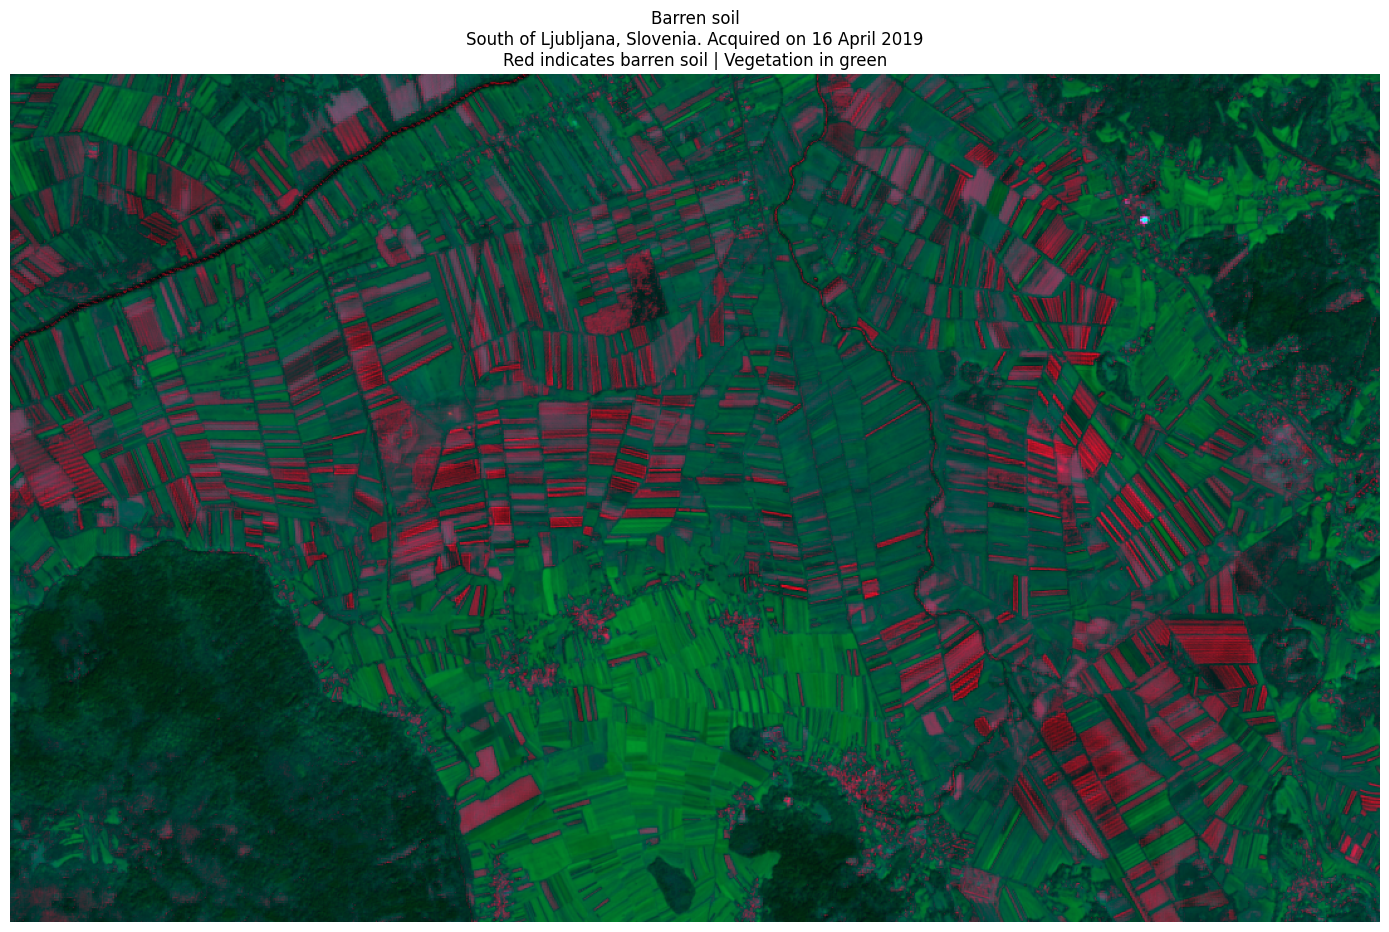

In [8]:
# Load and display the image
img = Image.open("barren_soil.png")

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    "Barren soil\n"
    "South of Ljubljana, Slovenia. Acquired on 16 April 2019\n"
    "Red indicates barren soil | Vegetation in green",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Applications
Detecting barren ground can help with:
- Figuring out the status of crops, whether crops are growing or not growing
- Detecting recent deforestation
- Monitoring droughts
- Detecting landslides
- Determining the extent of erosion in non-vegetated areas

## Limitations
- The script also highlights certain buildings, making bare ground areas difficult to separate from dwellings

## Citation
Nguyen, C.T., Chidthaisong, A., Diem, P.K., Huo, L-Z. (2021). *A Modified Bare Soil Index to Identify Bare Land Features during Agricultural Fallow-Period in Southeast Asia Using Landsat 8*. Land, 10(3), 231. https://doi.org/10.3390/land10030231

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Barren Soil Script)](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/barren_soil/)

**Author:** Monja Sebela

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.